# Concept Detection Score Plotting Helpers

We will be plotting detection score vs layer for different K values and mode(mlp vs residual)

Utility functions for exploring `interp_results.json`.

In [50]:
import json
import math
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


def load_interp_results(path="../experiments/artifacts/interp_results.json"):
    p = Path(path)
    with p.open("r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise ValueError(f"Expected list in {p}, got {type(data).__name__}")
    return data


def count_entries_for_layer_k(results, layer, k):
    """Return count of entries matching (layer, K)."""
    return sum(1 for e in results if int(e.get("layer", -1)) == int(layer) and int(e.get("K", -1)) == int(k))


def count_entries_by_layer_k(results):
    """Return {(layer, K): count} for all pairs found."""
    counts = Counter((int(e["layer"]), int(e["K"])) for e in results if "layer" in e and "K" in e)
    return dict(sorted(counts.items(), key=lambda kv: (kv[0][0], kv[0][1])))


def _safe_mean(values):
    vals = [float(v) for v in values if v is not None]
    return float(np.mean(vals)) if vals else np.nan


def _cosine_list(score_dict):
    if not isinstance(score_dict, dict):
        return []
    cos = score_dict.get("cosine", [])
    return cos if isinstance(cos, list) else []


def build_log_ratio_dataframe(results, eps=1e-12, k_values=None, layers=None, modes=None, top_m_values=None):
    """
    Build per-entry dataframe with:
      log_ratio = log(avg(scores.cosine) / avg(random_scores.cosine))

    Returns columns: layer, K, h_row, mode, top_m, log_ratio
    """
    allowed_k = None if k_values is None else set(int(k) for k in k_values)
    allowed_layers = None if layers is None else set(int(l) for l in layers)
    allowed_modes = None if modes is None else set(str(m).lower() for m in modes)
    allowed_top_m = None if top_m_values is None else set(int(m) for m in top_m_values)

    rows = []
    for idx, e in enumerate(results):
        if "layer" not in e or "K" not in e:
            continue

        # top_m is required for top_m-vs-score plots
        if "top_m" not in e:
            continue

        layer = int(e["layer"])
        k = int(e["K"])
        mode = str(e.get("mode", "unknown")).lower()
        top_m = int(e["top_m"])

        if top_m <= 0:
            continue
        if allowed_k is not None and k not in allowed_k:
            continue
        if allowed_layers is not None and layer not in allowed_layers:
            continue
        if allowed_modes is not None and mode not in allowed_modes:
            continue
        if allowed_top_m is not None and top_m not in allowed_top_m:
            continue

        s_avg = _safe_mean(_cosine_list(e.get("scores", {})))
        r_avg = _safe_mean(_cosine_list(e.get("random_scores", {})))
        if np.isnan(s_avg) or np.isnan(r_avg):
            continue

        ratio = (s_avg + eps) / (r_avg + eps)
        if ratio <= 0:
            continue

        rows.append({
            "layer": layer,
            "K": k,
            "h_row": int(e.get("h_row", idx)),
            "mode": mode,
            "top_m": top_m,
            "log_ratio": math.log(ratio),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No valid rows found after filtering; cannot build dataframe.")

    return df.sort_values(["layer", "top_m", "K", "mode", "h_row"]).reset_index(drop=True)



In [53]:
def plot_log_scores_vs_top_m_by_layer_box(
    results,
    k_values=None,
    layers=None,
    modes=("mlp", "residual"),
    top_m_values=None,
    eps=1e-12,
    ncols=2,
    figsize_per_plot=(6, 4),
    style="white",
    center_single_last_row=True,
):
    """
    Production-grade plotting helper (boxplot-only):
    - Computes per-entry log-ratio score
    - Creates separate subplot per layer
    - X-axis = top_m, Y-axis = concept detection (log-ratio)
    - Optional mode comparison (hue)

    Returns: (df, fig, axes)
      df columns: [layer, K, h_row, mode, top_m, log_ratio]
    """
    sns.set_theme(style=style)

    mode_order = [str(m).lower() for m in modes] if modes is not None else None
    df = build_log_ratio_dataframe(
        results,
        eps=eps,
        k_values=k_values,
        layers=layers,
        modes=mode_order,
        top_m_values=top_m_values,
    )

    if mode_order is None:
        mode_order = sorted(df["mode"].unique().tolist())

    layer_order = sorted(df["layer"].unique().tolist())
    top_m_order = sorted(df["top_m"].unique().tolist())

    n = len(layer_order)
    ncols = max(1, min(ncols, n))
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        squeeze=False,
    )
    axes_flat = axes.flatten()

    for i, layer in enumerate(layer_order):
        ax = axes_flat[i]
        sub = df[df["layer"] == layer].copy()

        sns.boxplot(
            data=sub,
            x="top_m",
            y="log_ratio",
            order=top_m_order,
            hue=None,
            hue_order=mode_order,
            ax=ax,
            width=0.45,
            showfliers=False,
        )

        ax.axhline(0.0, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)
        ax.set_title(f"Layer={layer}")
        ax.set_xlabel("top_m")
        ax.set_ylabel("Concept detection")
        ax.grid(False)
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))

        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(title="Mode")

    # Hide any unused subplot slots
    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle("Concept detection scores vs top_m (by layer)", y=1.02, fontsize=13)
    fig.tight_layout()

    # If the final row has a single plotted axis, center it horizontally.
    if center_single_last_row and ncols > 1 and (n % ncols == 1):
        last_ax = axes_flat[n - 1]
        pos = last_ax.get_position()
        last_ax.set_position([0.5 - (pos.width / 2.0), pos.y0, pos.width, pos.height])

    return df, fig, axes


# Data path requested
results = load_interp_results("../experiments/artifacts/interp_results.json")




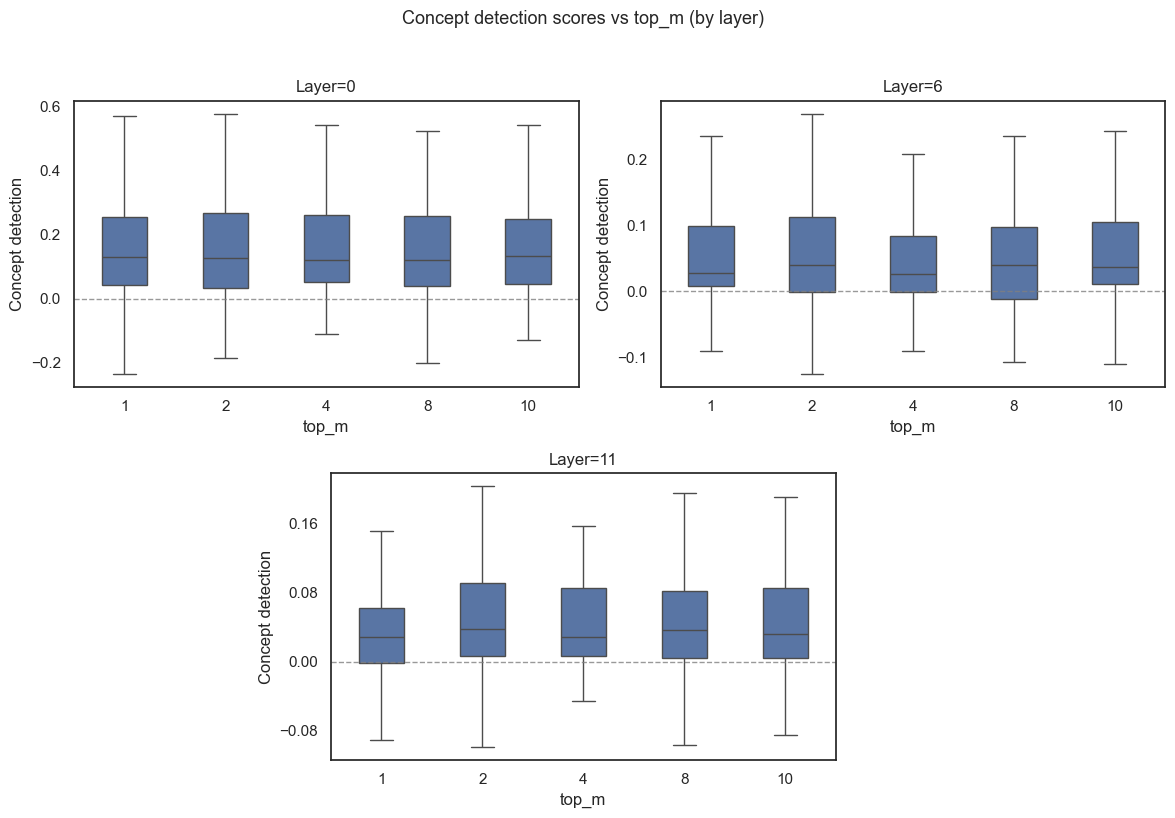

In [54]:
df, fig, axes = plot_log_scores_vs_top_m_by_layer_box(results, modes=None)


In [34]:
# Existing helper usage
results = load_interp_results("../experiments/artifacts/interp_results.json")
print("Entries for layer=0, K=100:", count_entries_for_layer_k(results, layer=0, k=100))
print("Total (layer, K) pairs:", len(count_entries_by_layer_k(results)))

pair_counts = count_entries_by_layer_k(results)
if not pair_counts:
    print("No (layer, K) entries found.")
else:
    print(f"{'Layer':>7}  {'K':>6}  {'Count':>8}")
    print("-" * 25)
    for (layer, k), count in pair_counts.items():
        print(f"{layer:>7}  {k:>6}  {count:>8}")


Entries for layer=0, K=100: 200
Total (layer, K) pairs: 20
  Layer       K     Count
-------------------------
      0     100       200
      0     200       400
      0     300       600
      0     400       800
      3     100       200
      3     200       400
      3     300       600
      3     400       800
      6     100       200
      6     200       400
      6     300       600
      6     400       800
      9     100       200
      9     200       400
      9     300       600
      9     400       800
     11     100       200
     11     200       400
     11     300       600
     11     400       800
